In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

from src import (
    # simulation & engine
    generate_scenarios,
    NoStop,
    TrailingStopRule,
    RatioVolScaledTrailingStop,
    run_backtest,

    # core analysis
    percentile_table,
    cvar_table,
    drawdown_summary,
    conditional_comparison,
    paired_comparison,
    bootstrap_ci,
    plot_distribution_overlay,
    combine_sleeves,

    # institutional
    institutional_summary,
    rolling_return_stats,
    dd_threshold_probabilities,
    stop_activity,
    plot_equity_fan,
    plot_drawdown_fan,
    plot_return_vs_dd_scatter,
    plot_did_stop_help,
    plot_historical_events,
    plot_survival_curve,
    plot_stopout_pct,

    # sensitivity
    sensitivity_to_L,
    sensitivity_to_rule_params,
)

pd.set_option('display.float_format', '{:.4f}'.format)


In [2]:
def generate_random_strategy_returns(
    start_date="2005-01-01",
    end_date="2015-12-31",
    strategy_names=None,
    annual_return=None,
    annual_vol=None,
    seed=42,
):
    """
    Generate random daily returns for multiple strategies.

    Returns
    -------
    pd.DataFrame
        Index  : business-day dates
        Columns: strategy names
        Values : simulated daily returns
    """

    if strategy_names is None:
        strategy_names = [
            "US Ten Stocks",
            "Europe Ten Stocks",
            "Long-Short",
        ]

    if annual_return is None:
        annual_return = {
            "US Ten Stocks": 0.10,
            "Europe Ten Stocks": 0.08,
            "Long-Short": 0.06,
        }

    if annual_vol is None:
        annual_vol = {
            "US Ten Stocks": 0.18,
            "Europe Ten Stocks": 0.16,
            "Long-Short": 0.10,
        }

    np.random.seed(seed)

    dates = pd.date_range(start=start_date, end=end_date, freq="B")

    n_days = len(dates)

    data = {}

    for strat in strategy_names:

        mu_daily = annual_return[strat] / 252
        sigma_daily = annual_vol[strat] / np.sqrt(252)

        returns = np.random.normal(
            loc=mu_daily,
            scale=sigma_daily,
            size=n_days,
        )

        data[strat] = returns

    stra_returns = pd.DataFrame(
        data,
        index=dates,
    )

    return stra_returns

stra_returns = generate_random_strategy_returns().reset_index().rename(columns={"index": "date"})

print(stra_returns.head())

        date  US Ten Stocks  Europe Ten Stocks  Long-Short
0 2005-01-03         0.0060             0.0127     -0.0037
1 2005-01-04        -0.0012            -0.0061      0.0009
2 2005-01-05         0.0077             0.0049      0.0024
3 2005-01-06         0.0177            -0.0207     -0.0060
4 2005-01-07        -0.0023            -0.0056      0.0004


In [3]:
stra_returns['date'] = pd.to_datetime(stra_returns['date'])
stra_returns = stra_returns.dropna()
stra_returns = stra_returns[stra_returns['date'] < '2016-01-01']

dates = stra_returns['date'].values

n = len(dates)
rng = np.random.default_rng(0)


def ar1(n, mu, sigma, phi):
    eps = rng.normal(0, sigma, n)
    r = np.zeros(n)

    for i in range(1, n):
        r[i] = mu + phi * (r[i - 1] - mu) + eps[i]

    return r


historical_returns = {
    'US Ten Stocks': stra_returns.set_index('date')['US Ten Stocks'],
    'Europe Ten Stocks': stra_returns.set_index('date')['Europe Ten Stocks'],
    'Long-Short': stra_returns.set_index('date')['Long-Short'],
}

# Per-strategy capital allocations
CAPITALS = {
    'US Ten Stocks': 9_430_000.0,
    'Europe Ten Stocks': 8_570_000.0,
    'Long-Short': 12_390_000.0,
}

# =============================================================================
# Stop rule parameters
# =============================================================================

TWO_RED_LEVELS = [(700_000, 0.70), (1_400_000, 0.40), (2_000_000, 0.00)]
ONE_RED_LEVELS = [(1_400_000, 0.40), (2_000_000, 0.00)]
HARD_LEVELS = [(2_000_000, 0.00)]

REENTRY_TWO_RED = 300_000
REENTRY_ONE_RED = 300_000
REENTRY_HARD = 0

# =============================================================================
# Factories (fresh rule instance per call — rules carry internal state)
# =============================================================================

def make_hard():
    return TrailingStopRule(
        levels=HARD_LEVELS,
        reentry_recovery=REENTRY_HARD,
        label="HardStop-2m"
    )


def make_one_red():
    return TrailingStopRule(
        levels=ONE_RED_LEVELS,
        reentry_recovery=REENTRY_ONE_RED,
        label="OneRed-1.4m40"
    )


def make_two_red():
    return TrailingStopRule(
        levels=TWO_RED_LEVELS,
        reentry_recovery=REENTRY_TWO_RED,
        label="TwoRed-700k70-1.4m40"
    )


def make_vol_one():
    return RatioVolScaledTrailingStop(
        base_levels=ONE_RED_LEVELS,
        base_reentry_recovery=REENTRY_ONE_RED,
        short_window=63,
        long_window=252,
        refresh_mode='monthly',
        vol_mult_cap=4.0,
        vol_mult_floor=0.25,
        label='OneRedVol-1.4m40'
    )


def make_vol_two():
    return RatioVolScaledTrailingStop(
        base_levels=TWO_RED_LEVELS,
        base_reentry_recovery=REENTRY_TWO_RED,
        short_window=252,
        long_window=63,
        refresh_mode='monthly',
        vol_mult_cap=4.0,
        vol_mult_floor=0.25,
        label='TwoRedVol-700k70-1.4m40'
    )


RULES = [
    ('baseline', lambda: NoStop()),
    ('hard', make_hard),
    ('one_red', make_one_red),
    ('two_red', make_two_red),
    # ('one_red_vol', make_vol_one),
    ('two_red_vol', make_vol_two)
]

RULE_LABEL = {
    'baseline': 'NoStop',
    'hard': 'HardStop-2m',
    'one_red': 'OneRed-1.4m40',
    'two_red': 'TwoRed-700k70-1.4m40',
    'one_red_vol': 'OneRedVol-1.4m40',
    'two_red_vol': 'TwoRedVol-700k70-1.4m40'
}

In [4]:
# =============================================================================
# Stop Rule Validation via Historical Time Series
# =============================================================================

strat_name = 'US Ten Stocks'
returns = historical_returns[strat_name].values
capital = CAPITALS[strat_name]

single_path = returns[np.newaxis, :]

rule = TrailingStopRule(
    levels=[(700_000, 0.70), (1_400_000, 0.40), (2_000_000, 0.00)],
    reentry_recovery=300_000,
    label='ValidationRule'
)

result = run_backtest(single_path, rule, strat_name, capital)

eq = result.equity_curves[0]
sizes = result.position_sizes[0]

hwm = np.maximum.accumulate(eq)
dd = hwm - eq

prev_size = np.concatenate(([1.0], sizes[:-1]))

event = np.where(
    sizes < prev_size,
    'CUT',
    np.where(sizes > prev_size, 'RAISE', '')
)

df = pd.DataFrame({
    'date': historical_returns[strat_name].index,
    'return': returns,
    'size_today': sizes,
    'equity_eod': eq[1:],
    'hwm': hwm[1:],
    'dd_£': dd[1:],
    'event': event
})

print(f"Strategy: {strat_name}, capital £{capital:,.0f}")
print(f"Total events: {(df.event != '').sum()}")
print(df[df.event != ''].to_string())

print(f"\nFinal equity: £{eq[-1]:,.0f}")
print(f"Total return: {eq[-1] / capital - 1:.4%}")
print(f"Max DD (£): £{dd.max():,.0f}")
print(f"Max DD (%): {(dd / hwm).max():.4%}")

Strategy: US Ten Stocks, capital £9,430,000
Total events: 35
           date  return  size_today    equity_eod           hwm         dd_£  event
20   2005-01-31  0.0170      0.7000  9241213.9756  9956460.1890  715246.2135    CUT
210  2005-10-24  0.0069      1.0000  9748353.8100  9956460.1890  208106.3790  RAISE
266  2006-01-10  0.0189      0.7000  9680838.0344 10304768.5514  623930.5170    CUT
307  2006-03-08 -0.0063      1.0000  9937583.9760 10304768.5514  367184.5754  RAISE
349  2006-05-05 -0.0020      0.7000 10192869.1243 10931272.9551  738403.8307    CUT
365  2006-05-29 -0.0042      1.0000 10492752.9862 10931272.9551  438519.9688  RAISE
433  2006-08-31  0.0085      0.7000 11697088.6095 12328069.9106  630981.3011    CUT
437  2006-09-06 -0.0153      1.0000 11823422.6553 12328069.9106  504647.2552  RAISE
439  2006-09-08 -0.0002      0.7000 11597858.3707 12328069.9106  730211.5399    CUT
460  2006-10-09  0.0227      0.4000 11004879.1719 12328069.9106 1323190.7387    CUT
823  2008-02-28

In [5]:
# =============================================================================
# Test lag1 ratio and ACF correlation with different L
# =============================================================================

hist_sq_acf = acf(
    historical_returns['US Ten Stocks'].values ** 2,
    nlags=20
)[1:]

for L in [13, 30, 60, 120, 180, 250]:

    sc = generate_scenarios(
        {'strat': historical_returns['US Ten Stocks']},
        n_paths=1000,
        path_length=2520,
        L_mean=L,
        seed=42
    )

    sim = sc['paths']['strat'][0]

    sim_sq_acf = acf(sim ** 2, nlags=20)[1:]

    corr = np.corrcoef(hist_sq_acf, sim_sq_acf)[0, 1]
    lag_ratio = sim_sq_acf[0] / hist_sq_acf[0]

    print(
        f"L={L:3d} | "
        f"lag1 ratio={lag_ratio:.2f} "
        f"ACF profile corr={corr:.3f}"
    )

L= 13 | lag1 ratio=3.16 ACF profile corr=0.413
L= 30 | lag1 ratio=2.77 ACF profile corr=0.834
L= 60 | lag1 ratio=1.45 ACF profile corr=0.861
L=120 | lag1 ratio=1.10 ACF profile corr=0.862
L=180 | lag1 ratio=1.02 ACF profile corr=0.899
L=250 | lag1 ratio=0.60 ACF profile corr=0.731


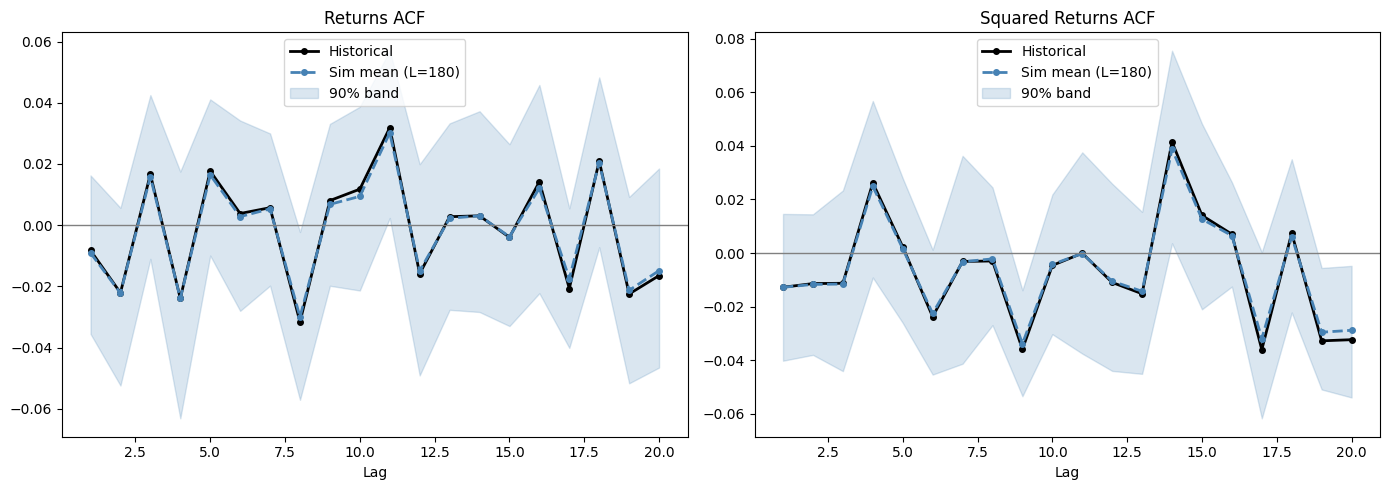

In [6]:
# =============================================================================
# ACF comparison
# =============================================================================

LAGS = 20
L = 180

hist_returns = historical_returns['US Ten Stocks'].values

sc = generate_scenarios(
    {'strat': historical_returns['US Ten Stocks']},
    n_paths=5000,
    path_length=2520,
    L_mean=L,
    seed=42
)

hist_acf = acf(hist_returns, nlags=LAGS)[1:]
hist_sq_acf = acf(hist_returns ** 2, nlags=LAGS)[1:]

N_PATHS = 5000

sim_acfs = np.array([
    acf(sc['paths']['strat'][p], nlags=LAGS)[1:]
    for p in range(N_PATHS)
])

sim_sq_acfs = np.array([
    acf(sc['paths']['strat'][p] ** 2, nlags=LAGS)[1:]
    for p in range(N_PATHS)
])

sim_acf_mean = sim_acfs.mean(axis=0)
sim_acf_p05 = np.quantile(sim_acfs, 0.05, axis=0)
sim_acf_p95 = np.quantile(sim_acfs, 0.95, axis=0)

sim_sq_acf_mean = sim_sq_acfs.mean(axis=0)
sim_sq_acf_p05 = np.quantile(sim_sq_acfs, 0.05, axis=0)
sim_sq_acf_p95 = np.quantile(sim_sq_acfs, 0.95, axis=0)

lags = np.arange(1, LAGS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, hist_vals, sim_mean, sim_lo, sim_hi, label in [
    (
        axes[0],
        hist_acf,
        sim_acf_mean,
        sim_acf_p05,
        sim_acf_p95,
        'Returns ACF'
    ),
    (
        axes[1],
        hist_sq_acf,
        sim_sq_acf_mean,
        sim_sq_acf_p05,
        sim_sq_acf_p95,
        'Squared Returns ACF'
    ),
]:

    ax.plot(
        lags,
        hist_vals,
        color='black',
        lw=2,
        marker='o',
        markersize=4,
        label='Historical'
    )

    ax.plot(
        lags,
        sim_mean,
        color='steelblue',
        lw=2,
        ls='--',
        marker='o',
        markersize=4,
        label=f'Sim mean (L={L})'
    )

    ax.fill_between(
        lags,
        sim_lo,
        sim_hi,
        color='steelblue',
        alpha=0.2,
        label='90% band'
    )

    ax.axhline(0, color='grey', lw=1)
    ax.set_title(label)
    ax.set_xlabel('Lag')
    ax.legend()

plt.tight_layout()


In [7]:
# =============================================================================
# STEP 1: generate scenarios ONCE, reuse for all strategies and rules
# =============================================================================

N_PATHS = 5000

print(f"Generating {N_PATHS:,} scenarios...")

scenarios = generate_scenarios(
    historical_returns=historical_returns,
    n_paths=N_PATHS,
    path_length=2520,
    L_mean=180,
    seed=42,
)

print(f"  Vols/white L per strategy: {scenarios['L_per_strategy']}")
print(f"  Block length used: L_mean = {scenarios['L_mean']:.1f}")
print(f"  Per-strategy capital: {CAPITALS}")

results = {}

for strat, paths in scenarios['paths'].items():

    cap = CAPITALS[strat]

    for rule_key, factory in RULES:

        results[(strat, rule_key)] = run_backtest(
            paths,
            factory(),
            strat,
            cap,
            quarterly_reset=True
        )

# =============================================================================
# Build combined-sleeve result per rule
# =============================================================================

for rule_key, _ in RULES:

    combined = combine_sleeves(
        results=results,
        strategies=list(historical_returns.keys()),
        rule_label=rule_key,
        capitals=CAPITALS,
        combined_name='combined',
    )

    combined.rule_name = RULE_LABEL[rule_key]

    results[('combined', rule_key)] = combined

all_results = list(results.values())
strategies_for_iter = list(historical_returns.keys()) + ['combined']

Generating 5,000 scenarios...
  Vols/white L per strategy: {'US Ten Stocks': 0.9320584213358233, 'Europe Ten Stocks': 1.6676693960137268, 'Long-Short': 1.9435179637182547}
  Block length used: L_mean = 180.0
  Per-strategy capital: {'US Ten Stocks': 9430000.0, 'Europe Ten Stocks': 8570000.0, 'Long-Short': 12390000.0}


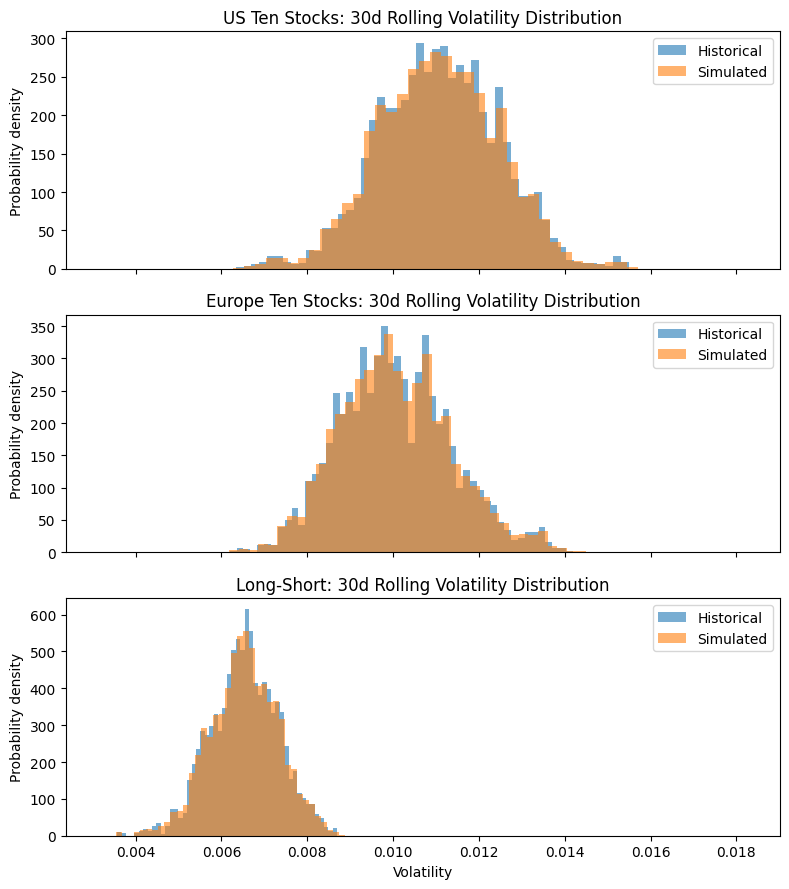

In [10]:
# =============================================================================
# Rolling volatility distribution validation
# =============================================================================

def rolling_vol(r, window=30):
    return pd.Series(r).rolling(window).std().dropna().values


strategies = scenarios['paths'].keys()

n = len(strategies)
fig, axes = plt.subplots(n, 1, figsize=(8, 3 * n), sharex=True)

if n == 1:
    axes = [axes]

for ax, strat in zip(axes, strategies):

    hist_vol = rolling_vol(historical_returns[strat])
    sim_paths = scenarios['paths'][strat]
    sim_vol = np.concatenate([
        rolling_vol(sim_paths[i])
        for i in range(len(sim_paths))
    ])

    ax.hist(hist_vol, bins=50, alpha=0.6, label='Historical', density=True)
    ax.hist(sim_vol, bins=50, alpha=0.6, label='Simulated', density=True)
    ax.set_title(f"{strat}: 30d Rolling Volatility Distribution")
    ax.set_ylabel('Probability density')
    ax.legend()

axes[-1].set_xlabel('Volatility')
plt.tight_layout()
plt.show()


In [11]:
# =============================================================================
# Correlation validation
# =============================================================================

hist_df = pd.DataFrame({k: v for k, v in historical_returns.items()})
print("Hist Corr:")
print(hist_df.corr())

corrs = []

for i in range(len(scenarios['paths']['US Ten Stocks'])):
    path_df = pd.DataFrame({
        k: v[i]
        for k, v in scenarios['paths'].items()
    })
    corrs.append(path_df.corr().values)

mean_corr = np.mean(corrs, axis=0)

print("Simulated Corr:")
print(pd.DataFrame(mean_corr, index=hist_df.columns, columns=hist_df.columns))


Hist Corr:
                   US Ten Stocks  Europe Ten Stocks  Long-Short
US Ten Stocks             1.0000             0.0034     -0.0192
Europe Ten Stocks         0.0034             1.0000     -0.0046
Long-Short               -0.0192            -0.0046      1.0000
Simulated Corr:
                   US Ten Stocks  Europe Ten Stocks  Long-Short
US Ten Stocks             1.0000             0.0034     -0.0191
Europe Ten Stocks         0.0034             1.0000     -0.0044
Long-Short               -0.0191            -0.0044      1.0000


In [12]:
# =============================================================================
# STEP 2: institutional summary + rolling / DD-threshold / activity tables
# =============================================================================

print("\n" + "=" * 100)
print("SIMULATION PERFORMANCE SUMMARY")
print("=" * 100)

summary = institutional_summary(
    all_results,
    dd_thresholds=(0.10, 0.15, 0.20, 0.30)
)

with pd.option_context(
    'display.max_columns', None,
    'display.width', 220,
    'display.float_format', '{:.3f}'.format,
):
    print(summary.to_string(index=False))

summary.to_csv('institutional_summary.csv', index=False)

roll_1y = pd.DataFrame([
    rolling_return_stats(r, 252)
    for r in all_results
])

dd_probs = pd.DataFrame([
    dd_threshold_probabilities(r, (0.05, 0.10, 0.15, 0.20, 0.30, 0.50))
    for r in all_results
])

activity = pd.DataFrame([
    stop_activity(r)
    for r in all_results
])

print("\n--- Rolling 1yr return distribution ---")
with pd.option_context(
    'display.float_format', '{:.3f}'.format,
    'display.max_columns', None,
    'display.width', 200,
):
    print(roll_1y.to_string(index=False))

print("\n--- Drawdown breach probabilities ---")
with pd.option_context('display.float_format', '{:.3f}'.format):
    print(dd_probs.to_string(index=False))

print("\n--- Stop activity (how often the rule actually fires) ---")
with pd.option_context('display.float_format', '{:.3f}'.format):
    print(activity.to_string(index=False))


SIMULATION PERFORMANCE SUMMARY


d:\PythonProjects\sizing_strategy\src\institutional.py:816: RuntimeWarning: invalid value encountered in power
  cagr = (tw / r.initial_capital) ** (1 / years) - 1


         strategy                    rule  mean_CAGR  median_CAGR  mean_Calmar  mean_maxDD_%  p95_maxDD_%  rolling_1yr_p05  CVaR05_return  prob_negative_5yr  P(maxDD>10%)  P(maxDD>15%)  P(maxDD>20%)  P(maxDD>30%)  mean_cash_out_total  pct_qtrs_positive  mean_qtrs_with_reset
    US Ten Stocks                  NoStop      0.203        0.200        0.230         0.894        1.310           -0.530          1.324              0.000         1.000         1.000         1.000         1.000         60059784.621              0.537                21.481
    US Ten Stocks             HardStop-2m      0.037        0.033        0.110         0.312        0.423           -0.162         -0.145              0.105         1.000         1.000         0.971         0.567          5920090.045              0.126                 5.022
    US Ten Stocks           OneRed-1.4m40      0.053        0.054        0.157         0.330        0.444           -0.157         -0.060              0.037         1.000     

In [13]:
# =============================================================================
# STEP 3: core diagnostics
# =============================================================================

print("\n" + "=" * 100)
print("CORE DIAGNOSTICS")
print("=" * 100)

pct_table = percentile_table(all_results)
cvar_t = cvar_table(all_results, alphas=(0.01, 0.05, 0.10))

print("\n--- Percentile table (terminal return and max DD) ---")
with pd.option_context(
    'display.max_columns', None,
    'display.width', 240,
    'display.float_format', '{:.3f}'.format,
):
    print(pct_table.to_string(index=False))

print("\n--- CVaR table ---")
with pd.option_context(
    'display.float_format', '{:.3f}'.format,
    'display.max_columns', None,
    'display.width', 200,
):
    print(cvar_t.to_string(index=False))

print("\n--- Drawdown dynamics (hit rates, time underwater, recovery) ---")
dd_rows = pd.DataFrame([
    drawdown_summary(r, TRIGGER_DOLLARS)
    for r in all_results
])

with pd.option_context(
    'display.max_columns', None,
    'display.width', 240,
    'display.float_format', '{:.3f}'.format,
):
    print(dd_rows.to_string(index=False))

print("\n--- Paired comparisons and bootstrap CIs ---")

paired_rows = []
ci_rows = []

# (a) Each treatment vs NoStop baseline: is any stop worth using?
for strat in strategies_for_iter:

    baseline = results[(strat, 'baseline')]

    for treated_key in ('hard', 'one_red', 'two_red'):

        treated = results[(strat, treated_key)]
        paired_rows.append(paired_comparison(treated, baseline))

        ci = bootstrap_ci(
            treated,
            baseline,
            'total_returns',
            n_resamples=2000
        )

        ci['strategy'] = strat
        ci['comparison'] = f'{RULE_LABEL[treated_key]} vs NoStop'
        ci_rows.append(ci)

# (b) Pairwise across treatments: does tiering improve on a simpler rule?
for strat in strategies_for_iter:

    for treated_key, anchor_key in [
        ('one_red', 'hard'),
        ('two_red', 'hard'),
        ('two_red', 'one_red'),
    ]:

        treated = results[(strat, treated_key)]
        anchor = results[(strat, anchor_key)]

        paired_rows.append(paired_comparison(treated, anchor))

        ci = bootstrap_ci(
            treated,
            anchor,
            'total_returns',
            n_resamples=2000
        )

        ci['strategy'] = strat
        ci['comparison'] = f'{RULE_LABEL[treated_key]} vs {RULE_LABEL[anchor_key]}'
        ci_rows.append(ci)

with pd.option_context(
    'display.float_format', '{:.4f}'.format,
    'display.max_columns', None,
    'display.width', 220,
):
    print(pd.DataFrame(paired_rows).to_string(index=False))
    print("\nBootstrap 95% CI on mean-return difference:")
    print(pd.DataFrame(ci_rows).to_string(index=False))


print("\n--- Conditional comparison (US Ten Stocks, TwoRed vs OneRed, bucketed by worst_30d) ---")
cond = conditional_comparison(
    results[('US Ten Stocks', 'two_red')],
    results[('US Ten Stocks', 'one_red')],
    bucket_by='worst_30d',
    n_buckets=5,
)

with pd.option_context(
    'display.float_format', '{:.3f}'.format,
    'display.max_columns', None,
    'display.width', 200,
):
    print(cond.to_string(index=False))

print("Does the additional stop help most in bucket 0 (worst-tail paths)?")


print("\n--- Conditional comparison (US Ten Stocks, TwoRedVol vs TwoRed, bucketed by worst_30d) ---")
cond = conditional_comparison(
    results[('US Ten Stocks', 'two_red_vol')],
    results[('US Ten Stocks', 'two_red')],
    bucket_by='worst_30d',
    n_buckets=5,
)

with pd.option_context(
    'display.float_format', '{:.3f}'.format,
    'display.max_columns', None,
    'display.width', 200,
):
    print(cond.to_string(index=False))

print("Does the additional stop help most in bucket 0 (worst-tail paths)?")


CORE DIAGNOSTICS

--- Percentile table (terminal return and max DD) ---
         strategy                    rule  tr_p01  tr_p05  tr_p25  tr_p50  tr_p75  tr_p95  tr_p99    dd_$_p01    dd_$_p05     dd_$_p25     dd_$_p50     dd_$_p75     dd_$_p95     dd_$_p99  dd_%_p01  dd_%_p05  dd_%_p25  dd_%_p50  dd_%_p75  dd_%_p95  dd_%_p99
    US Ten Stocks                  NoStop   1.041   1.781   3.401   5.175   7.741  13.885  20.637 5589128.590 7417648.138 11506967.265 15775161.226 22351177.702 37513272.013 54487744.995     0.462     0.557     0.730     0.869     1.031     1.310     1.539
    US Ten Stocks             HardStop-2m  -0.184  -0.095   0.171   0.384   0.742   1.413   2.026 2018930.218 2122507.399  2963094.625  3621259.680  4381687.678  5739670.630  7287873.789     0.194     0.207     0.265     0.310     0.356     0.423     0.485
    US Ten Stocks           OneRed-1.4m40  -0.129   0.041   0.363   0.696   1.039   1.683   2.260 2014732.761 2367818.173  3260549.455  3937997.876  4762895

NameError: name 'TRIGGER_DOLLARS' is not defined

In [ ]:
# =============================================================================
# STEP 4: plots
# =============================================================================

rule_keys_for_plots = ['baseline', 'hard', 'one_red', 'two_red']

# Distribution overlays for all strategies x all rules.
fig, axes = plt.subplots(
    2,
    len(strategies_for_iter),
    figsize=(5 * len(strategies_for_iter), 9)
)

for j, strat in enumerate(strategies_for_iter):

    plot_distribution_overlay(
        [results[(strat, k)] for k in rule_keys_for_plots],
        metric='total_returns',
        ax=axes[0, j],
        title=f'{strat}: terminal return'
    )

    plot_distribution_overlay(
        [results[(strat, k)] for k in rule_keys_for_plots],
        metric='max_drawdown_pct',
        ax=axes[1, j],
        title=f'{strat}: max DD %'
    )

plt.tight_layout()
plt.savefig('distribution_overlays.png', dpi=120)
plt.close()
print("\nSaved distribution_overlays.png")


# One-pager per strategy:
# Top row: equity fan + DD fan for all 4 rules.
# Bottom-left: return-vs-DD scatter for all 4.
# Bottom-right: did-it-help histogram comparing TwoRed to HardStop.
# For strat in strategies_for_iter:
#     b = results[(strat, 'baseline')]
#     hard = results[(strat, 'hard')]
#     oner = results[(strat, 'one_red')]
#     twor = results[(strat, 'two_red')]
#
#     fig, axes = plt.subplots(2, 2, figsize=(16, 10))
#
#     plot_equity_fan([b, hard, oner, twor], ax=axes[0, 0])
#     axes[0, 0].set_title(f'{strat}: equity fan (all rules)')
#
#     plot_drawdown_fan([b, hard, oner, twor], ax=axes[0, 1])
#     axes[0, 1].set_title(f'{strat}: drawdown fan (all rules)')
#
#     plot_return_vs_dd_scatter([b, hard, oner, twor], ax=axes[1, 0])
#     axes[1, 0].set_title(f'{strat}: return vs max DD')
#
#     plot_did_stop_help(twor, hard, ax=axes[1, 1])
#     axes[1, 1].set_title(f'{strat}: TwoRed vs HardStop per-path delta')
#
#     plt.tight_layout()
#     plt.savefig(f"one_pager_{strat.replace(' ', '_').replace('-', '_')}.png", dpi=120)
#     plt.close()

<Axes: title={'center': 'US Ten Stocks: TwoRedVol vs TwoRed by market regime'}, xlabel='Mean terminal return delta (treated − baseline)'>

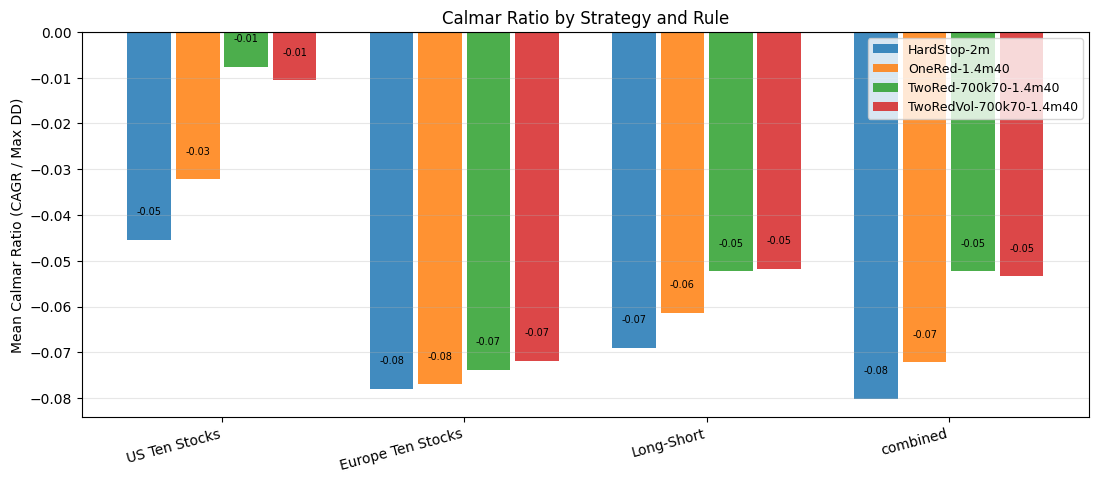

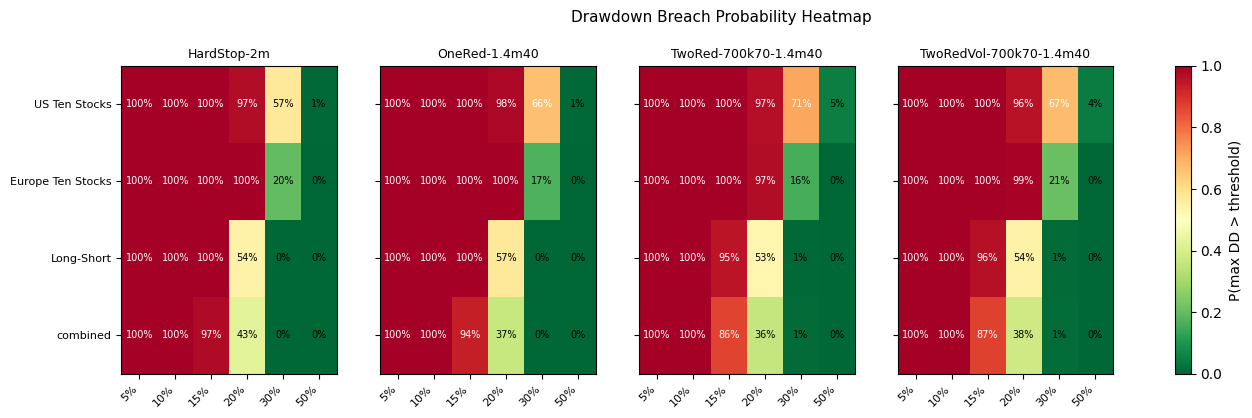

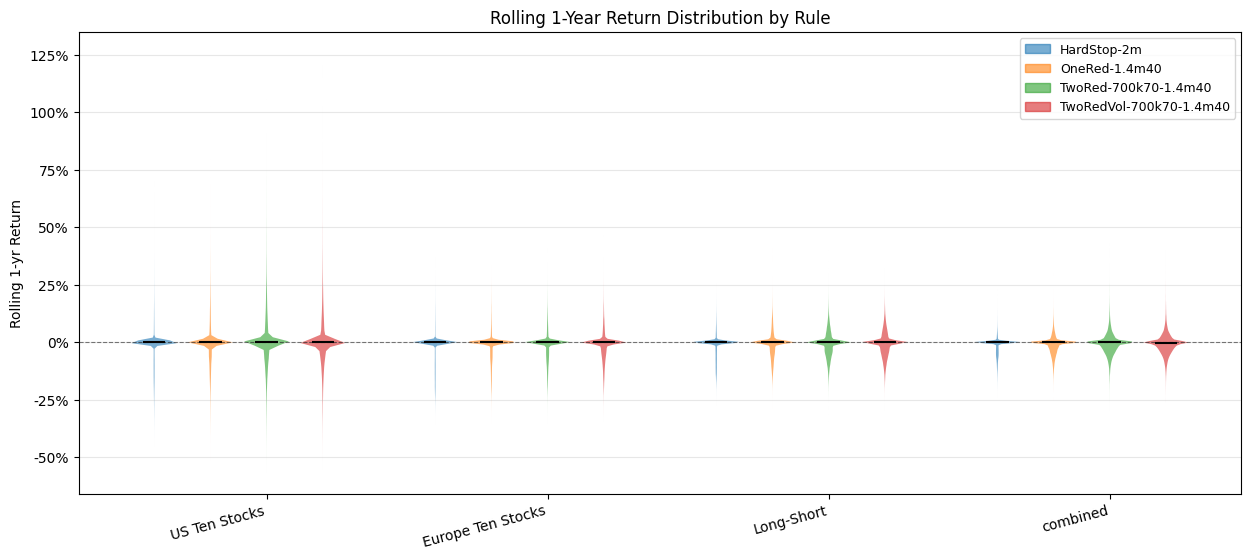

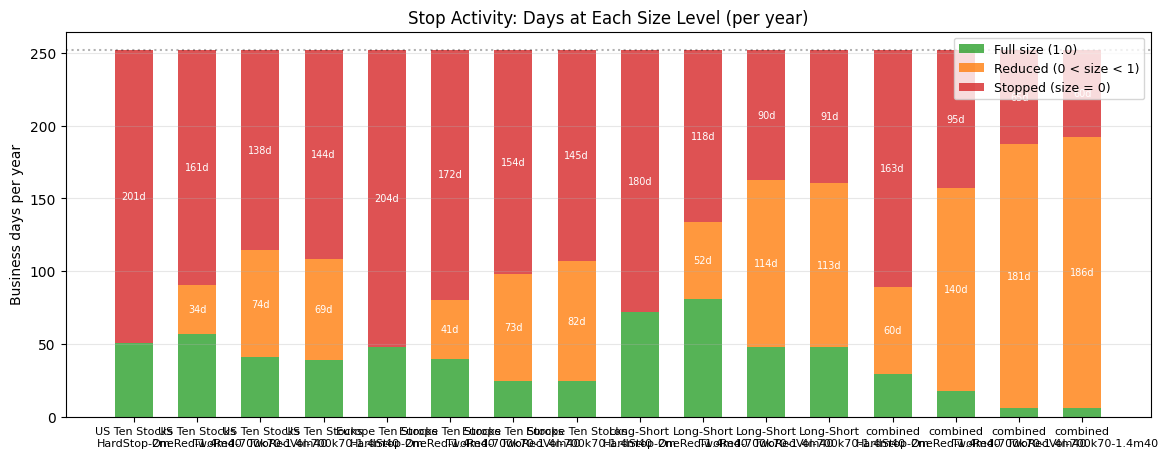

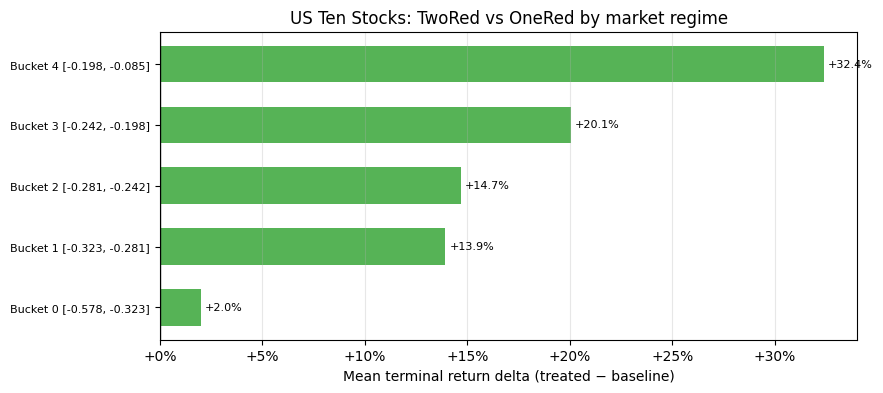

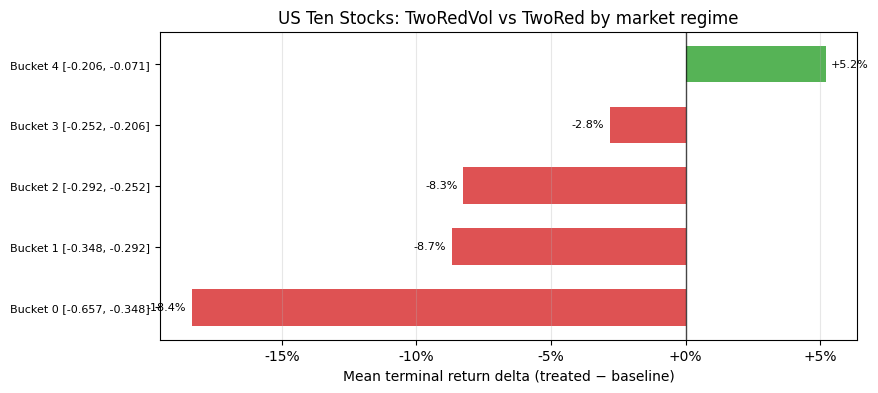

In [14]:
# =============================================================================
# Additional dashboard-style plots
# =============================================================================

all_results[0].rule_name
# with_stop = [i for i in all_results if i.rule_name != 'NoStop' and 'VolOneRed' not in i.rule_name and i.rule_name != 'OneRedVol-1.4m40']
with_stop = [i for i in all_results if i.rule_name != 'NoStop']


from src import (
    plot_calmar_bar,
    plot_dd_breach_heatmap,
    plot_rolling_return_violin,
    plot_stop_activity_bar,
    plot_conditional_diverging,
    conditional_comparison,
)

# Headline charts (opening section)
fig, ax = plt.subplots(figsize=(13, 5))
plot_calmar_bar(with_stop, ax=ax)

plot_dd_breach_heatmap(with_stop)  # creates its own figure

fig, ax = plt.subplots(figsize=(15, 6))
plot_rolling_return_violin(with_stop, ax=ax)

# Operational cost
fig, ax = plt.subplots(figsize=(14, 5))
plot_stop_activity_bar(with_stop, ax=ax)

# When does the stop help?
cond = conditional_comparison(
    results[('US Ten Stocks', 'two_red')],
    results[('US Ten Stocks', 'one_red')],
    bucket_by='worst_30d',
    n_buckets=5
)

fig, ax = plt.subplots(figsize=(9, 4))
plot_conditional_diverging(
    cond,
    ax=ax,
    title='US Ten Stocks: TwoRed vs OneRed by market regime'
)

# When does the stop help?
cond = conditional_comparison(
    results[('US Ten Stocks', 'two_red_vol')],
    results[('US Ten Stocks', 'two_red')],
    bucket_by='worst_30d',
    n_buckets=5
)

fig, ax = plt.subplots(figsize=(9, 4))
plot_conditional_diverging(
    cond,
    ax=ax,
    title='US Ten Stocks: TwoRedVol vs TwoRed by market regime'
)



US Ten Stocks / OneRed  (11.4 years of history)
  Cuts:   3  (0.3/yr)
  Raises: 1  (0.1/yr)
  First cut: 2005-03-08   size → 40%
  Last cut:  2007-03-12  size → 0%
  Mean days between cuts: 262
  Cuts within 10 days of previous cut: 0 (OK)


,date,return,size_today,equity_eod,hwm,dd_£,event,vol_mult
20,2005-01-31,0.0170,0.7000,9241213.9756,9956460.1890,715246.2135,CUT,1.0000
210,2005-10-24,0.0069,1.0000,9748353.8100,9956460.1890,208106.3790,RAISE,1.0000
269,2006-01-13,0.0019,0.7000,9549569.6665,10304768.5514,755198.8849,CUT,1.0898
304,2006-03-03,0.0002,1.0000,9880054.4396,10304768.5514,424714.1117,RAISE,1.0852
348,2006-05-04,-0.0077,0.7000,10275982.7567,10979073.9559,703091.1992,CUT,0.8304
373,2006-06-08,0.0113,1.0000,10846903.2397,10979073.9559,132170.7162,RAISE,0.7800
384,2006-06-23,-0.0082,0.7000,10782909.7331,11446359.3100,663449.5769,CUT,0.8380
395,2006-07-10,-0.0049,1.0000,11104625.4725,11446359.3100,341733.8375,RAISE,0.8380
413,2006-08-03,0.0149,0.7000,10818237.7171,11446359.3100,628121.5929,CUT,0.9740
420,2006-08-14,0.0238,1.0000,11314244.8015,11446359.3100,132114.5085,RAISE,1.0162


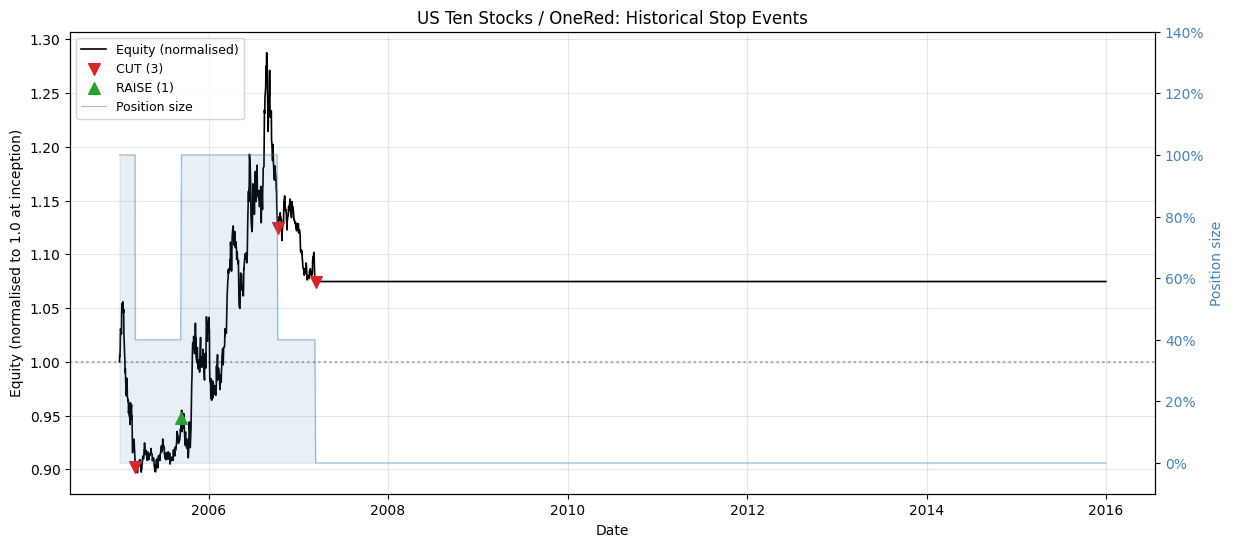

In [20]:
# =============================================================================
# Extra historical event validation and vol-scaled event diagnostics
# =============================================================================

# Historical event plot: OneRed validation
strat_name = 'US Ten Stocks'
returns = historical_returns[strat_name].values
capital = CAPITALS[strat_name]

single_path = returns[np.newaxis, :]

rule = TrailingStopRule(
    levels=ONE_RED_LEVELS,
    reentry_recovery=REENTRY_ONE_RED,
    label='OneRed',
)

result = run_backtest(single_path, rule, strat_name, capital)

eq = result.equity_curves[0]
sizes = result.position_sizes[0]
hwm = np.maximum.accumulate(eq)
dd = hwm - eq

prev_size = np.concatenate(([1.0], sizes[:-1]))
event = np.where(
    sizes < prev_size,
    'CUT',
    np.where(sizes > prev_size, 'RAISE', '')
)

df = pd.DataFrame({
    'date': historical_returns[strat_name].index,
    'return': returns,
    'size_today': sizes,
    'equity_eod': eq[1:],
    'hwm': hwm[1:],
    'dd_£': dd[1:],
    'event': event,
})

plot_historical_events(
    historical_returns['US Ten Stocks'],
    TrailingStopRule(
        levels=ONE_RED_LEVELS,
        reentry_recovery=REENTRY_ONE_RED,
        label='OneRed',
    ),
    'US Ten Stocks',
    initial_capital=CAPITALS['US Ten Stocks'],
)


# Historical event table: RatioVolScaledTrailingStop validation
strat_name = 'US Ten Stocks'
returns = historical_returns[strat_name].values
capital = CAPITALS[strat_name]

single_path = returns[np.newaxis, :]

rule = RatioVolScaledTrailingStop(
    base_levels=TWO_RED_LEVELS,
    base_reentry_recovery=REENTRY_TWO_RED,
    short_window=252,
    long_window=63,
    refresh_mode='monthly',
    label='TwoRedVol'
)

result = run_backtest(single_path, rule, strat_name, capital)

eq = result.equity_curves[0]
sizes = result.position_sizes[0]
hwm = np.maximum.accumulate(eq)
dd = hwm - eq
vol_mult = result.vol_mult_log[0]

prev_size = np.concatenate(([1.0], sizes[:-1]))
event = np.where(
    sizes < prev_size,
    'CUT',
    np.where(sizes > prev_size, 'RAISE', '')
)

df = pd.DataFrame({
    'date': historical_returns[strat_name].index,
    'return': returns,
    'size_today': sizes,
    'equity_eod': eq[1:],
    'hwm': hwm[1:],
    'dd_£': dd[1:],
    'event': event,
    'vol_mult': vol_mult,
})

df[df['event'] != '']

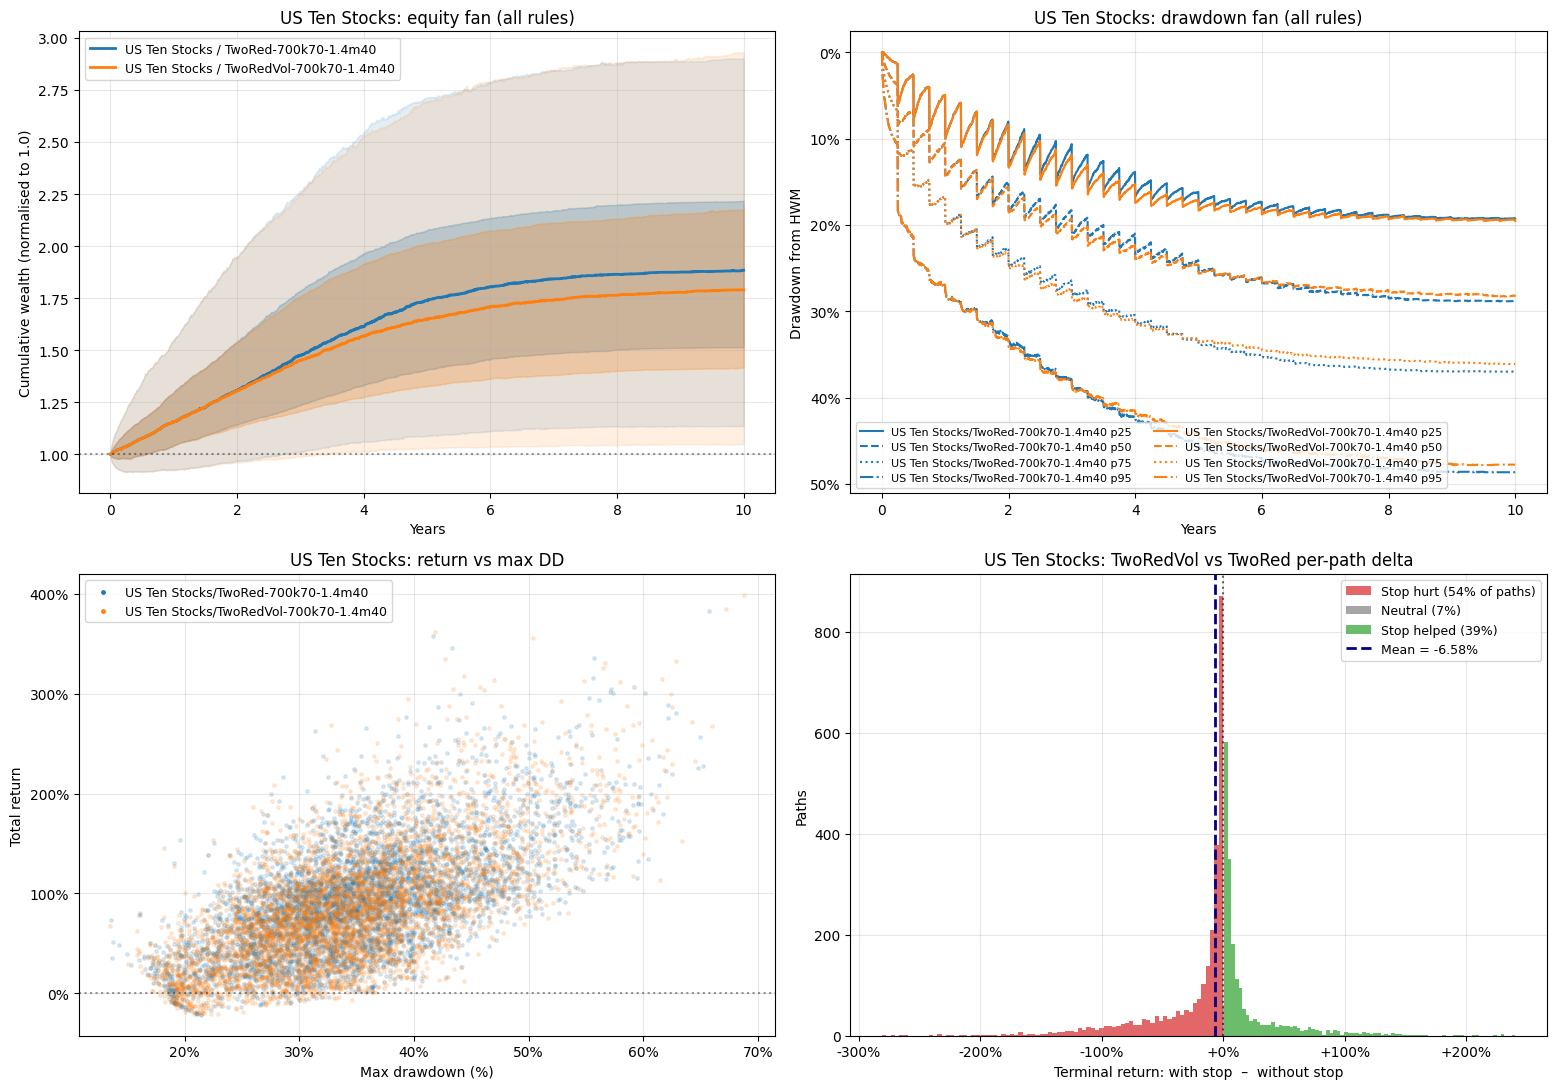

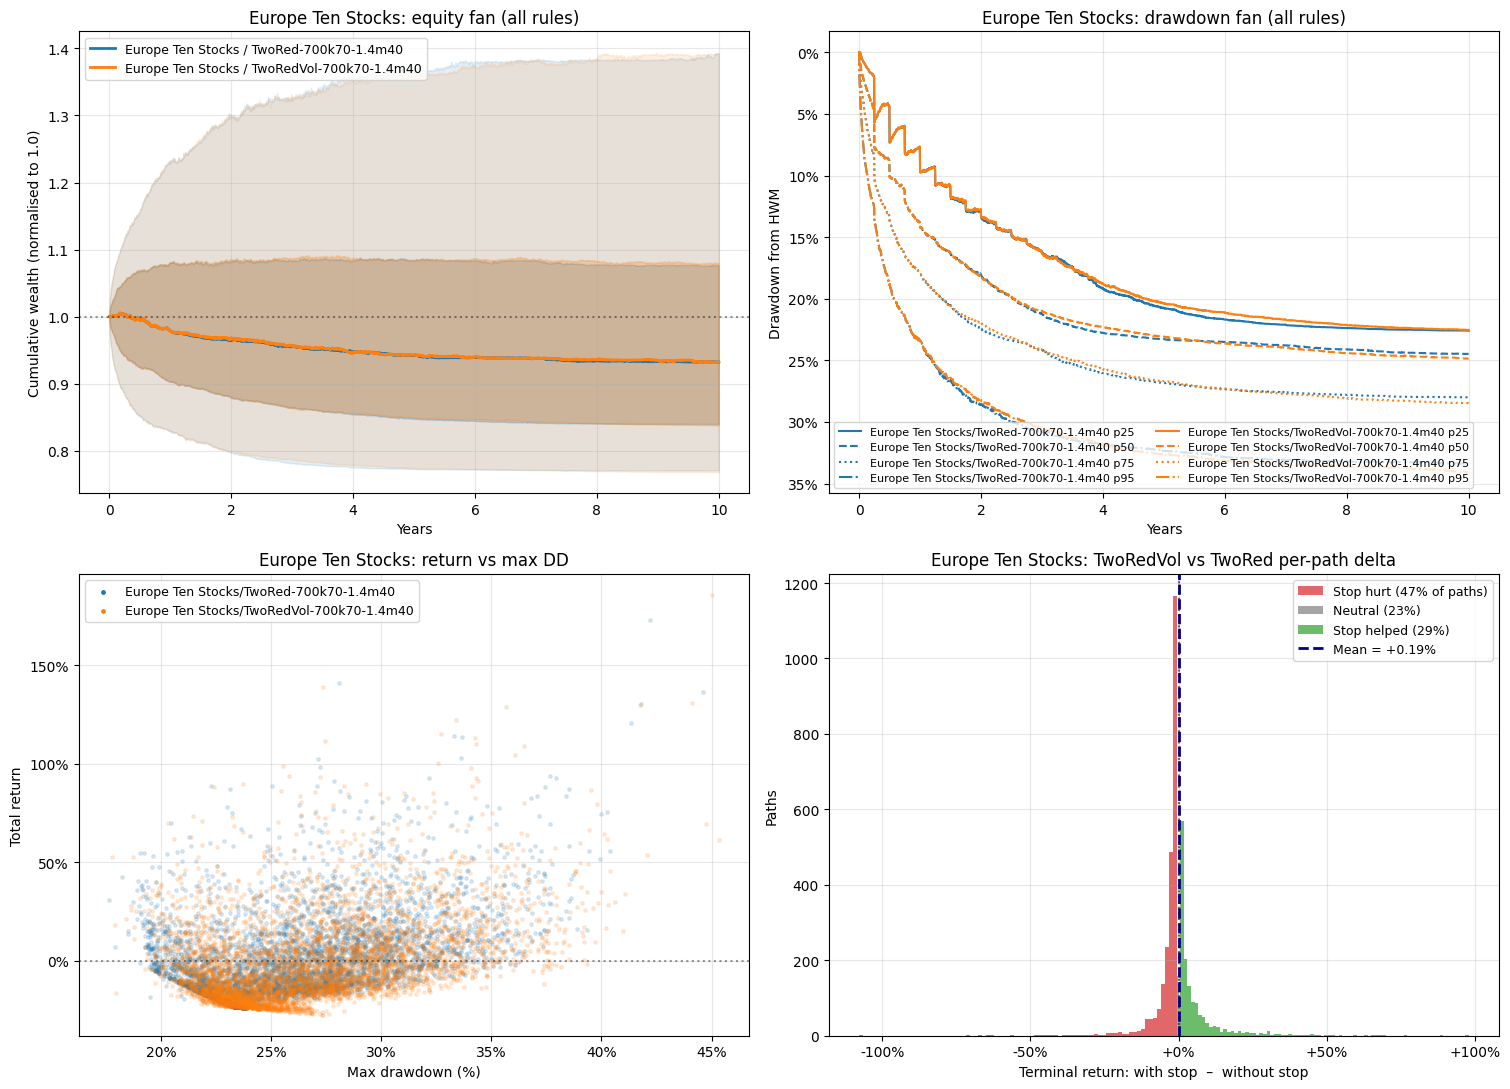

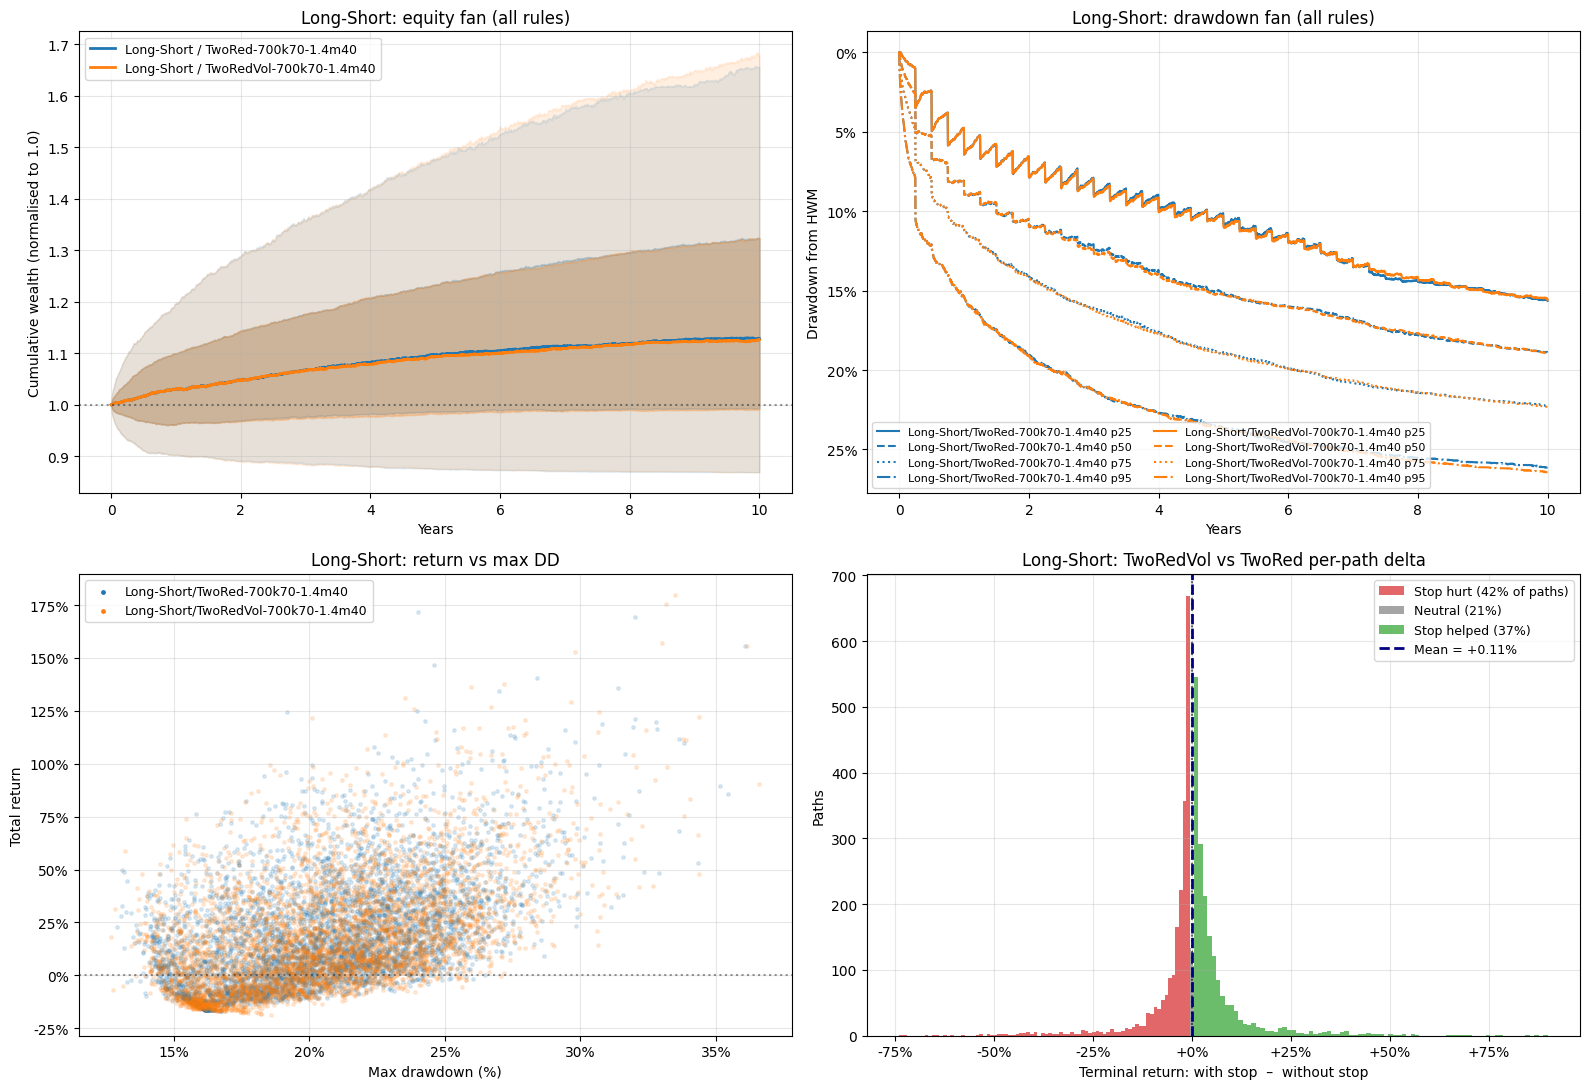

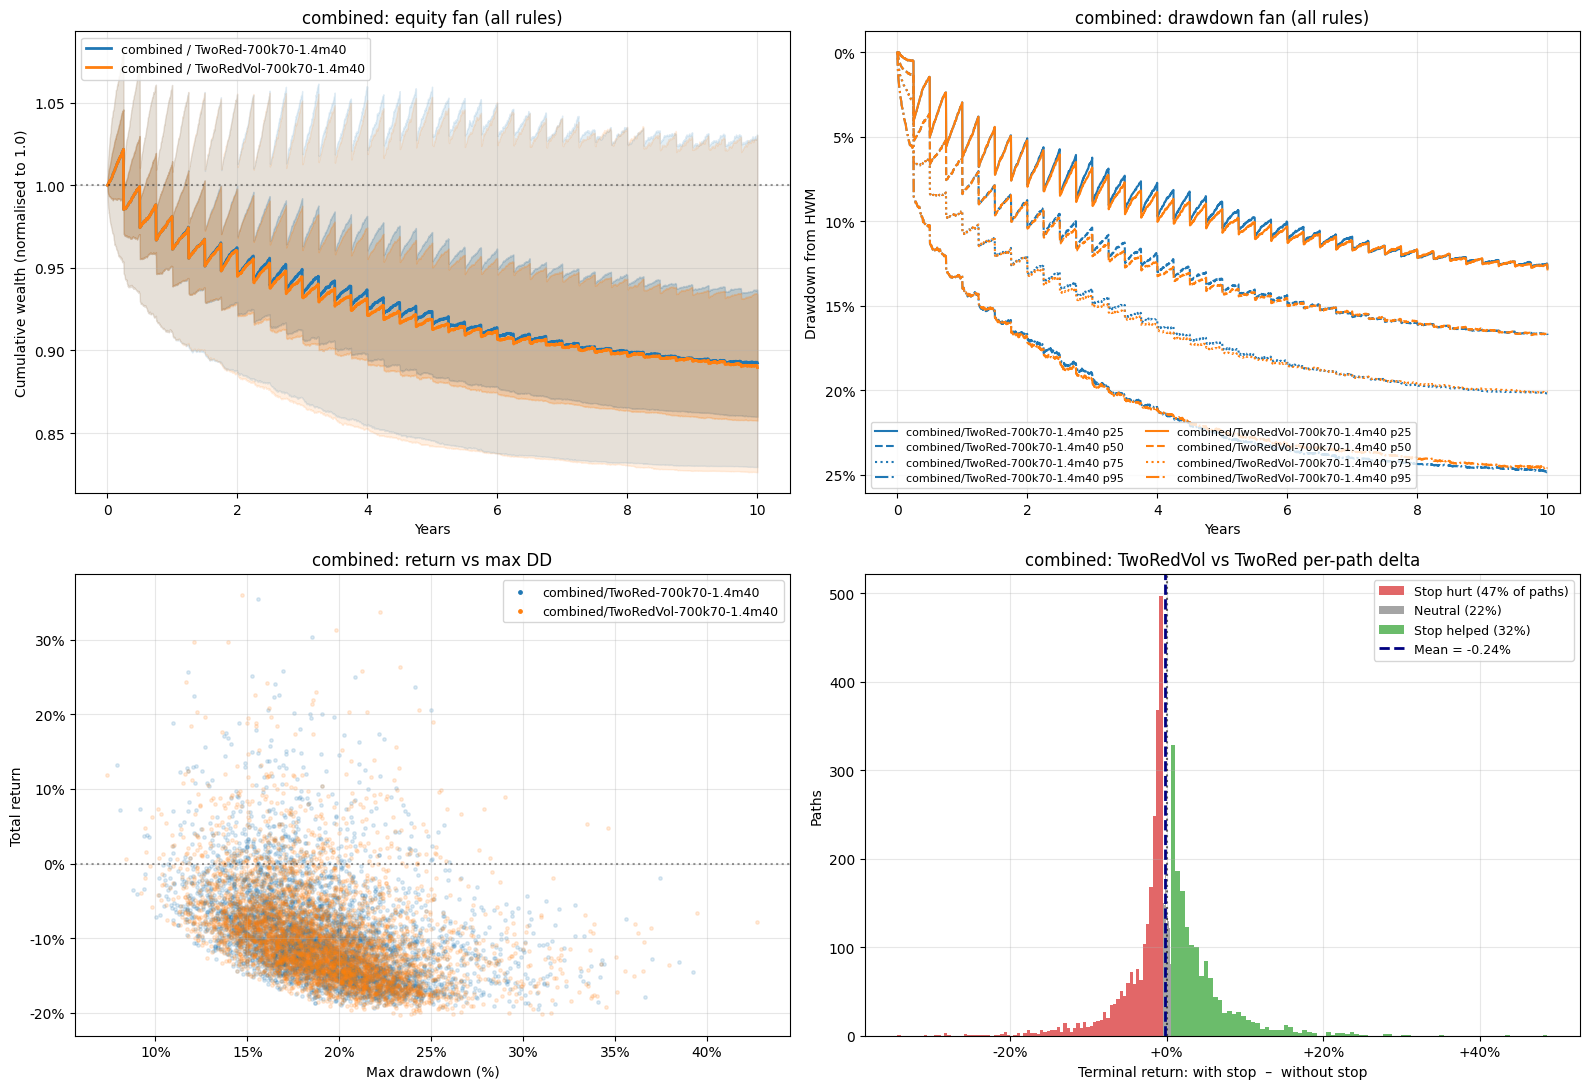

In [21]:
# =============================================================================
# One-pager plots: compare TwoRed and TwoRedVol
# =============================================================================

for strat in strategies_for_iter:
    twoR = results[(strat, 'two_red')]
    twoRVol = results[(strat, 'two_red_vol')]

    fig, axes = plt.subplots(2, 2, figsize=(16, 11))

    plot_equity_fan(
        [twoR, twoRVol],
        ax=axes[0, 0],
        title=f'{strat}: equity fan (all rules)'
    )

    plot_drawdown_fan(
        [twoR, twoRVol],
        ax=axes[0, 1],
        title=f'{strat}: drawdown fan (all rules)'
    )

    plot_return_vs_dd_scatter(
        [twoR, twoRVol],
        ax=axes[1, 0],
        title=f'{strat}: return vs max DD'
    )

    plot_did_stop_help(
        twoRVol,
        twoR,
        ax=axes[1, 1],
        title=f'{strat}: TwoRedVol vs TwoRed per-path delta'
    )

    plt.tight_layout()
    plt.show()

<Axes: title={'center': 'Size-Change Event Density Over Simulated Time\n(rolling 21-day window)'}, xlabel='Years into simulated path', ylabel='Mean events per 21-day window (avg across paths)'>

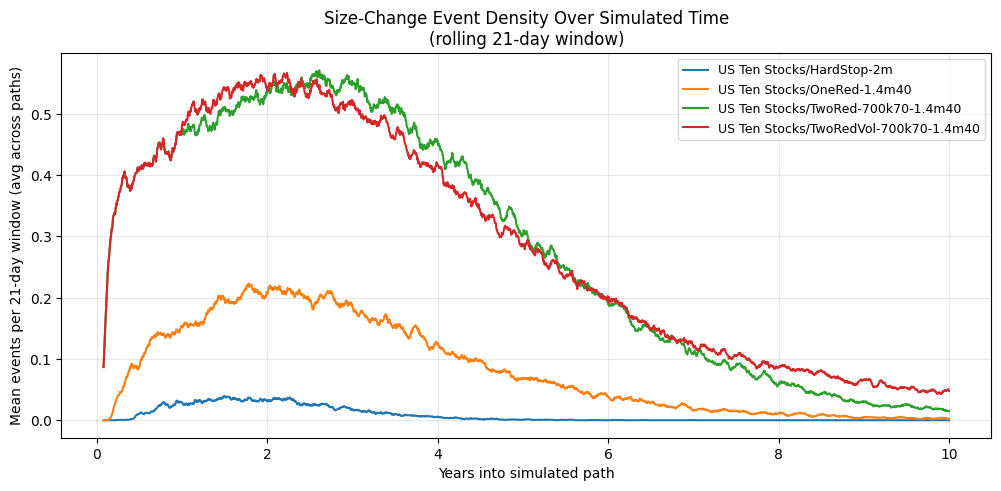

In [23]:
# =============================================================================
# Size-change event density plot
# =============================================================================

from src import plot_size_change_frequency, plot_historical_events, TrailingStopRule

fig, ax = plt.subplots(figsize=(12, 5))
plot_size_change_frequency(
    [
        results[('US Ten Stocks', 'hard')],
        results[('US Ten Stocks', 'one_red')],
        results[('US Ten Stocks', 'two_red')],
        # results[('US Ten Stocks', 'one_red_vol')],
        results[('US Ten Stocks', 'two_red_vol')],
    ],
    ax=ax,
    window_days=21,
)

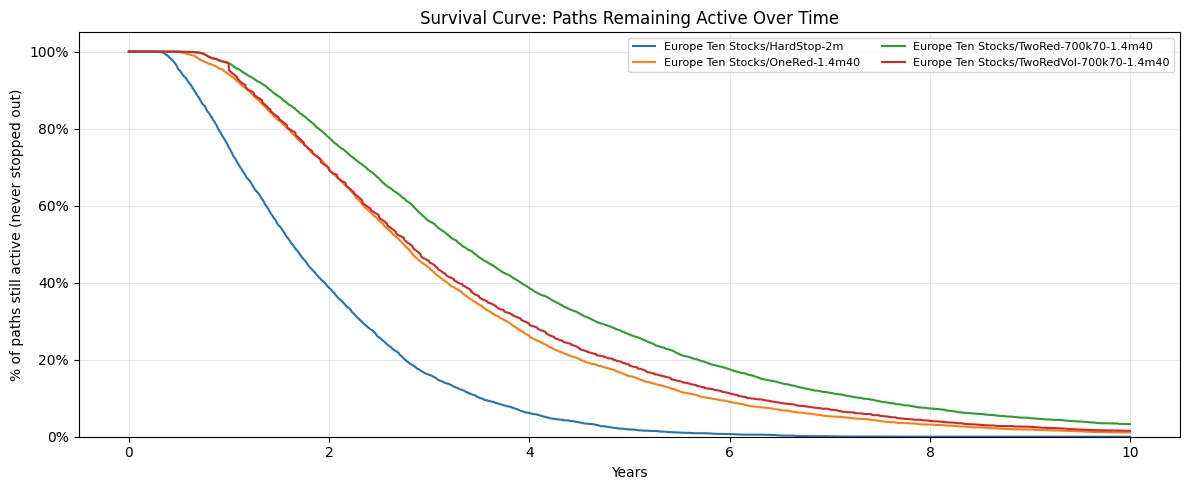

In [28]:

fig, ax = plt.subplots(figsize=(12, 5))
plot_survival_curve(
    results,
    strategies=['Europe Ten Stocks'],
    rules=['hard', 'one_red', 'two_red', 'two_red_vol'],
    ax=ax,
)
plt.tight_layout()

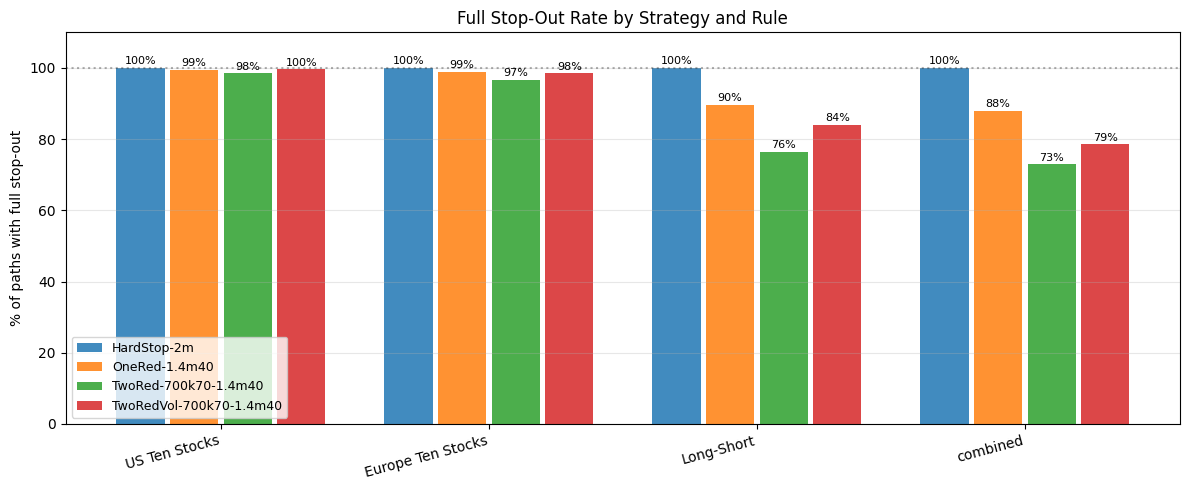

In [30]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_stopout_pct(
    results,
    strategies=['US Ten Stocks', 'Europe Ten Stocks', 'Long-Short', 'combined'],
    rules=['hard', 'one_red', 'two_red', 'two_red_vol'],
    ax=ax,
)
plt.tight_layout()

In [31]:
# =============================================================================
# STEP 5: robustness sensitivity sweeps
# =============================================================================

print("\n" + "=" * 100)
print("SENSITIVITY TO BOOTSTRAP BLOCK LENGTH L")
print("=" * 100)
print("Re-running each rule at L = 10, 30, 60, 120, 250 with per-strategy capital...")

# sensitivity_to_L now accepts a dict for initial_capital, so we can pass all strategies in a single call.
# The module does the per-strategy lookup. One call per treatment rule, then concat the results.
sens_pieces = []

for rule_key in ('hard', 'one_red', 'two_red'):
    factory = dict(RULES)[rule_key]

    df = sensitivity_to_L(
        historical_returns=historical_returns,
        rule_factory=factory,
        L_values=[10, 30, 60, 120, 250],
        n_paths=3000,
        path_length=1260,
        initial_capital=CAPITALS,  # dict -> per-strategy capital
        seed=42,
    )

    sens_pieces.append(df)

sens_L = pd.concat(sens_pieces, ignore_index=True)

# Drop duplicate NoStop rows if helper returns one per factory call.
sens_L = sens_L.drop_duplicates(subset=['L_mean', 'strategy', 'rule'])

pivot_tr = sens_L.pivot_table(
    index='L_mean',
    columns=['strategy', 'rule'],
    values='mean_total_return'
)

with pd.option_context(
    'display.float_format', '{:.4f}'.format,
    'display.max_columns', None,
    'display.width', 220,
):
    print("\nMean total return by L:")
    print(pivot_tr.to_string())


print("\n" + "=" * 100)
print("SENSITIVITY TO RULE PARAMETERS (varies the TwoRed structure only)")
print("=" * 100)

# Rule-parameter sensitivity tests whether the rule is robust to small changes
# in threshold levels — a question about overfitting, not capital calibration.
# We use a single representative capital (momentum's $10m) for simplicity.
# If you want per-strategy rule sensitivity, wrap this loop similarly to above.

level_variants = [
    [(500_000, 0.70), (1_000_000, 0.40), (2_000_000, 0.0)],  # tight (-25%)
    [(700_000, 0.70), (1_400_000, 0.40), (2_000_000, 0.0)],  # base
    [(900_000, 0.70), (1_700_000, 0.40), (2_000_000, 0.0)],  # loose (+25%)
]

sens_p = sensitivity_to_rule_params(
    scenarios=scenarios['paths'],
    level_variants=level_variants,
    reentry_variants=[0, 150_000, 300_000, 500_000],
    initial_capital=CAPITALS['US Ten Stocks'],
)

pivot_p = sens_p.pivot_table(
    index=['variant_idx', 'reentry_recovery'],
    columns='strategy',
    values='mean_total_return',
)

with pd.option_context('display.float_format', '{:.4f}'.format):
    print("\nMean total return by (variant, reentry) per strategy:")
    print(pivot_p.to_string())

print("\nVariant 0 = tight (-25%), 1 = base, 2 = loose (+25%)")
print("Smooth gradients across variants = robust. Sharp differences = overfit.")

# sens_L.to_csv('sensitivity_L.csv', index=False)
# sens_p.to_csv('sensitivity_params.csv', index=False)
# activity.to_csv('stop_activity.csv', index=False)
print("\nAll CSVs saved in the current working directory.")


SENSITIVITY TO BOOTSTRAP BLOCK LENGTH L
Re-running each rule at L = 10, 30, 60, 120, 250 with per-strategy capital...

Mean total return by L:
strategy Europe Ten Stocks                                             Long-Short                                           US Ten Stocks                                          
rule           HardStop-2m  NoStop OneRed-1.4m40 TwoRed-700k70-1.4m40 HardStop-2m NoStop OneRed-1.4m40 TwoRed-700k70-1.4m40   HardStop-2m NoStop OneRed-1.4m40 TwoRed-700k70-1.4m40
L_mean                                                                                                                                                                             
10                 -0.0133 -0.0240       -0.0160              -0.0167      0.1295 0.2277        0.1367               0.1365        0.5681 1.7174        0.7199               0.7922
30                 -0.0049 -0.0151       -0.0062              -0.0100      0.1466 0.2384        0.1459               0.1449        0.564

TypeError: sensitivity_to_rule_params() got an unexpected keyword argument 'scenarios'